# 02 - Preprocessing and Feature Engineering Report

This report section focuses on the image-processing steps that help panorama stitching become more stable. We start from image representation and basic operators, then end with a configurable preprocessing pipeline that we can run on a single image, a chosen scene, or the full dataset.

## 1. Setup and Data Loading

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import glob
import os


def show_images(images, titles, figsize=(15, 5), color_spaces=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    if color_spaces is None:
        color_spaces = ["rgb"] * n
    elif isinstance(color_spaces, str):
        color_spaces = [color_spaces] * n

    for i, (img, title) in enumerate(zip(images, titles)):
        if img.ndim == 2:
            axes[i].imshow(img, cmap="gray")
        else:
            color_space = color_spaces[i] if i < len(color_spaces) else "rgb"
            if color_space == "bgr":
                display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            elif color_space == "rgb":
                display_img = img
            else:
                raise ValueError(f"Unsupported color_space: {color_space}")
            axes[i].imshow(display_img)
        axes[i].set_title(title)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()


image_files = sorted(glob.glob("../data/split/failure_analysis/scene_18/*.jpg"))
if image_files:
    img_bgr = cv2.imread(image_files[0])
else:
    print("No split image found, please extract the dataset to data/split first.")
    img_bgr = np.random.randint(0, 255, (300, 400, 3), dtype=np.uint8)

img_bgr = cv2.resize(img_bgr, (600, 400))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image shape:", img_bgr.shape)


Image shape: (400, 600, 3)


## 2. Image Representation, Channels, and Color Spaces

OpenCV loads color images in **BGR** order, while Matplotlib expects **RGB**. If we forget that conversion, the colors look wrong even though the pixels are still valid. For feature extraction we normally reduce the image to grayscale, but color spaces like LAB are also useful when we want to enhance local contrast more carefully.

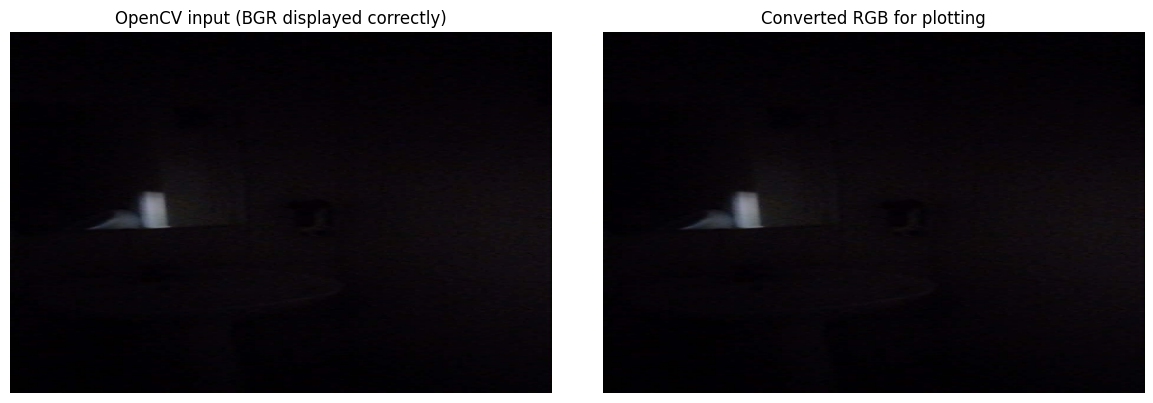

In [2]:
show_images(
    [img_bgr, img_rgb],
    ["OpenCV input (BGR displayed correctly)", "Converted RGB for plotting"],
    figsize=(12, 4),
    color_spaces=["bgr", "rgb"],
)


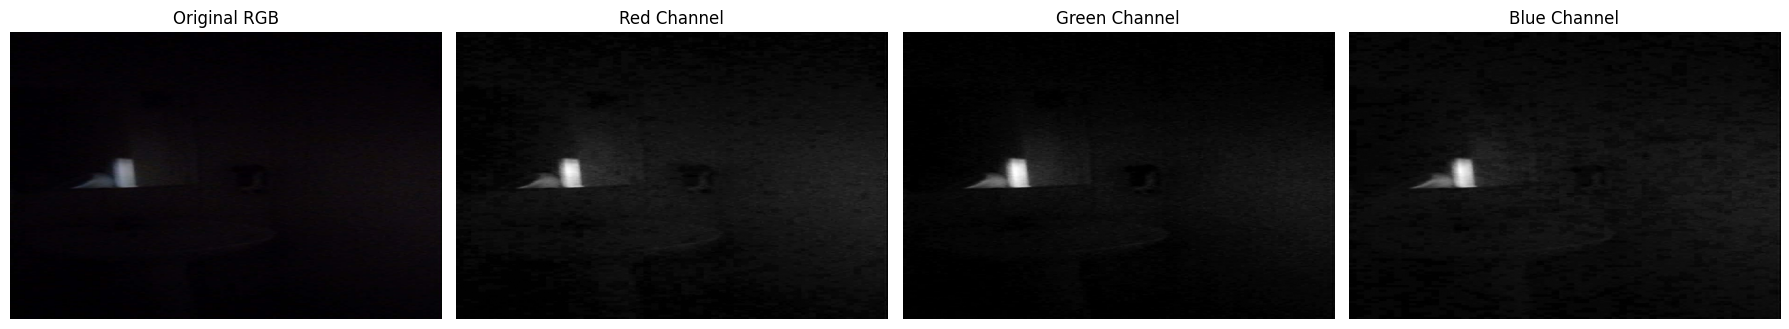

In [3]:
# --- 1.1 Show RGB Channels ---
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

show_images(
    [img_rgb, R, G, B],
    ["Original RGB", "Red Channel", "Green Channel", "Blue Channel"],
    figsize=(18, 5),
    color_spaces=["rgb", "rgb", "rgb", "rgb"],
)


Max difference between scratch and OpenCV: 1


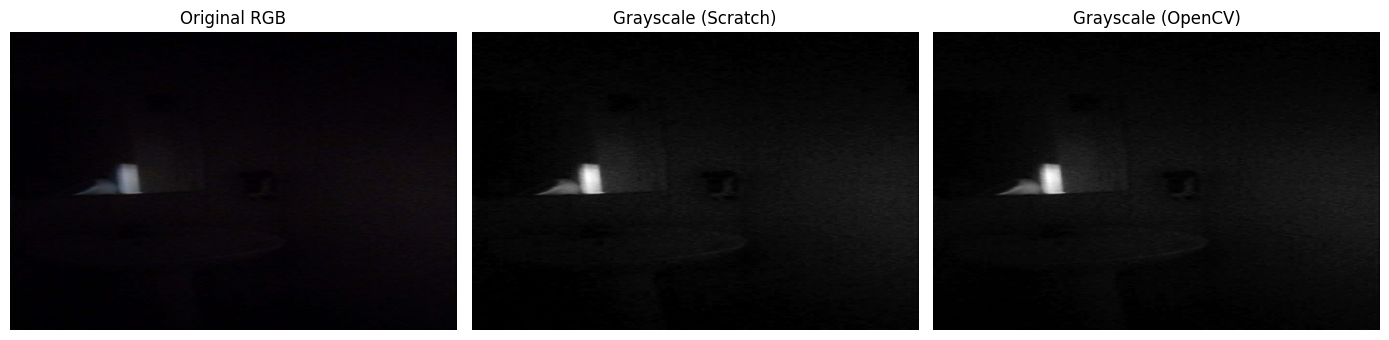

In [4]:
# --- 1.2 Grayscale Conversion FROM SCRATCH ---
# Standard BT.601 luminance: Y = 0.299*R + 0.587*G + 0.114*B
def rgb_to_grayscale_scratch(img_rgb):
    weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
    gray = np.dot(img_rgb[..., :3], weights)
    return gray.astype(np.uint8)


gray_scratch = rgb_to_grayscale_scratch(img_rgb)
gray_cv2 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

diff = cv2.absdiff(gray_scratch, gray_cv2)
print("Max difference between scratch and OpenCV:", np.max(diff))

show_images(
    [img_rgb, gray_scratch, gray_cv2],
    ["Original RGB", "Grayscale (Scratch)", "Grayscale (OpenCV)"],
    figsize=(14, 4),
    color_spaces=["rgb", "gray", "gray"],
)


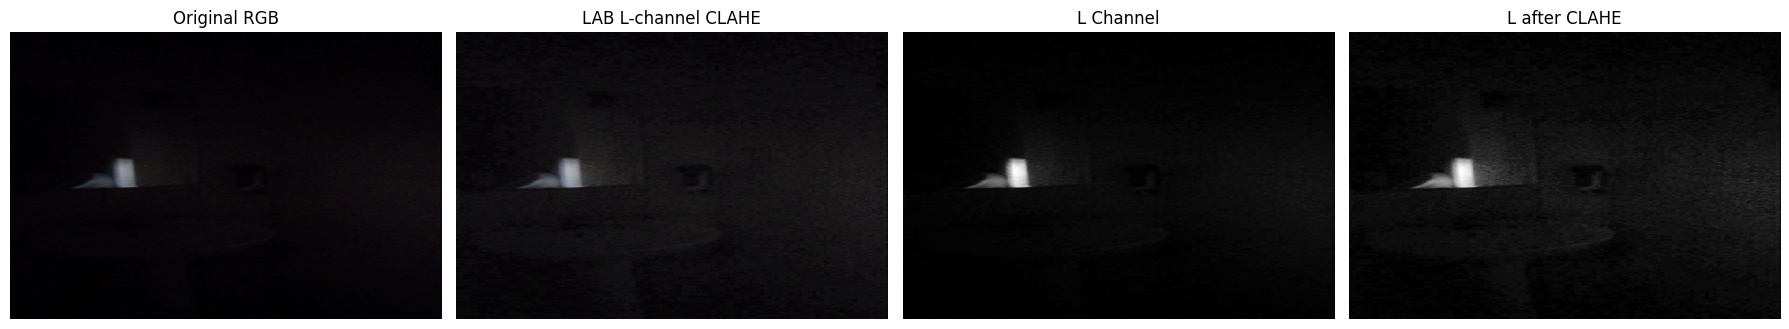

In [5]:
# --- 1.3 LAB Color Space Preview ---
# LAB separates lightness (L) from color channels (A/B), which is handy when we only want
# to boost local contrast without distorting colors too aggressively.
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, A, B_lab = cv2.split(img_lab)

lab_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
L_boosted = lab_clahe.apply(L)
img_lab_boosted = cv2.merge([L_boosted, A, B_lab])
img_lab_boosted_rgb = cv2.cvtColor(img_lab_boosted, cv2.COLOR_LAB2RGB)

show_images(
    [img_rgb, img_lab_boosted_rgb, L, L_boosted],
    ["Original RGB", "LAB L-channel CLAHE", "L Channel", "L after CLAHE"],
    figsize=(18, 5),
    color_spaces=["rgb", "rgb", "gray", "gray"],
)


## 3. Point Operations and Contrast Enhancement

Point operations update each pixel independently. For low-light or flat images, histogram-based methods can improve contrast before keypoint detection.

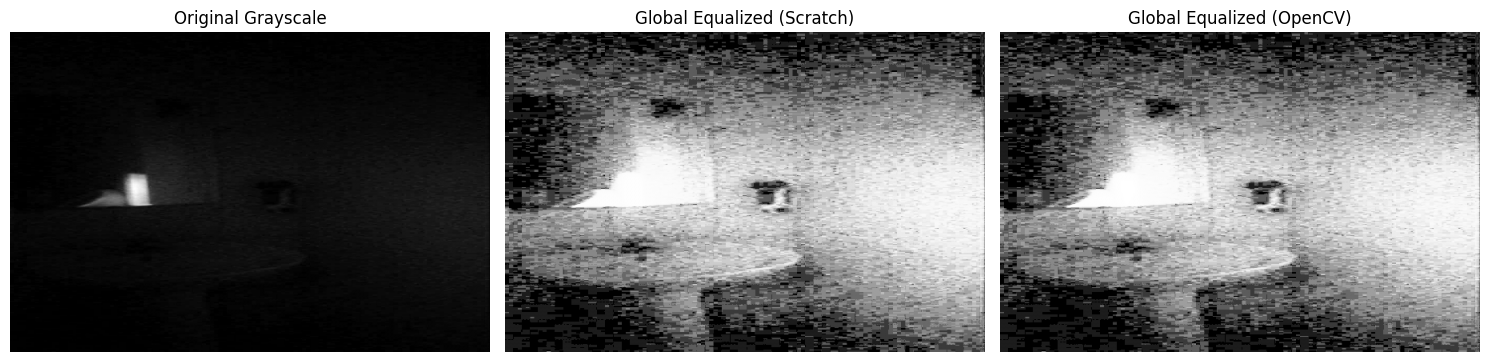

In [6]:
# --- 2.1 Global Histogram Equalization FROM SCRATCH ---
def hist_equalization_scratch(gray_img):
    hist, _ = np.histogram(gray_img.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype("uint8")
    return cdf_final[gray_img]


img_eq_scratch = hist_equalization_scratch(gray_scratch)
img_eq_cv2 = cv2.equalizeHist(gray_scratch)

show_images(
    [gray_scratch, img_eq_scratch, img_eq_cv2],
    ["Original Grayscale", "Global Equalized (Scratch)", "Global Equalized (OpenCV)"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


### Why CLAHE is usually better for panorama features
Global equalization can over-stretch already bright regions. CLAHE works tile-by-tile, so we keep more useful local detail for feature detection.

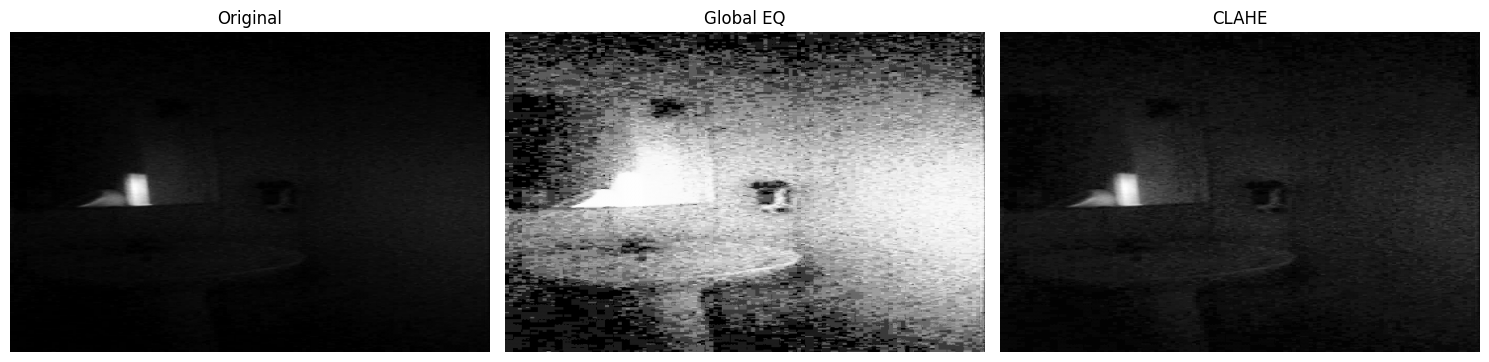

In [7]:
# --- 2.2 CLAHE using OpenCV ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(gray_scratch)

show_images(
    [gray_scratch, img_eq_scratch, img_clahe],
    ["Original", "Global EQ", "CLAHE"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


Estimated gamma: 0.700


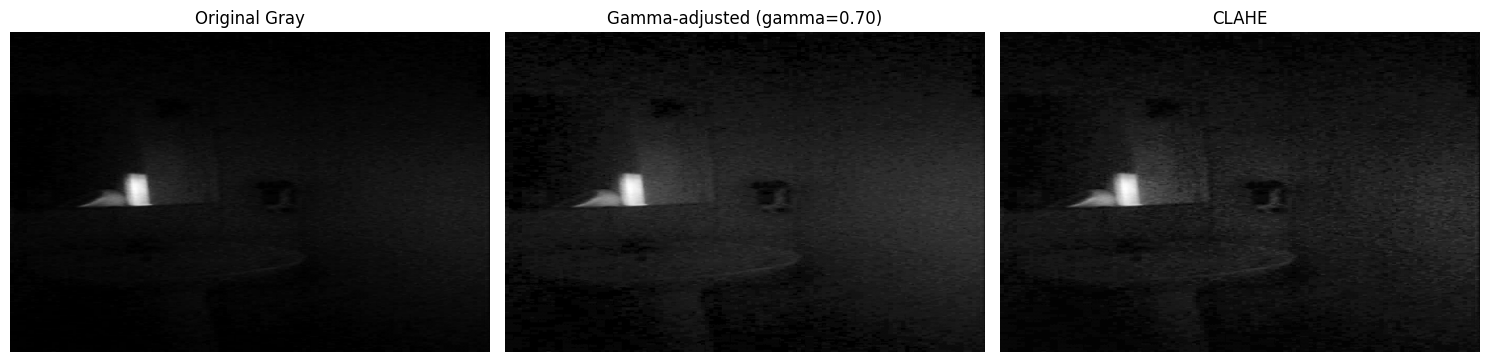

In [8]:
# --- 2.3 Automatic Brightness Normalization ---
def adjust_gamma(gray_img, gamma):
    # gamma < 1 brightens dark images; gamma > 1 darkens bright images.
    gamma = max(float(gamma), 1e-4)
    lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(gray_img, lut)


def estimate_auto_gamma(gray_img, target_mean=128.0, gamma_min=0.7, gamma_max=1.5):
    current_mean = float(gray_img.mean())
    if current_mean <= 1.0 or current_mean >= 254.0:
        return 1.0
    current_norm = np.clip(current_mean / 255.0, 1e-4, 1 - 1e-4)
    target_norm = np.clip(target_mean / 255.0, 1e-4, 1 - 1e-4)
    gamma = np.log(target_norm) / np.log(current_norm)
    return float(np.clip(gamma, gamma_min, gamma_max))


auto_gamma = estimate_auto_gamma(gray_scratch)
gray_gamma = adjust_gamma(gray_scratch, auto_gamma)
print(f"Estimated gamma: {auto_gamma:.3f}")

show_images(
    [gray_scratch, gray_gamma, img_clahe],
    ["Original Gray", f"Gamma-adjusted (gamma={auto_gamma:.2f})", "CLAHE"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


## 4. Spatial Filtering, Denoising, and Sharpening

Spatial filters depend on neighboring pixels. For stitching, we usually want a gentle filter that suppresses noise without destroying corners.

Mathematical Gaussian Kernel:
 [[0.014 0.028 0.035 0.028 0.014]
 [0.028 0.055 0.068 0.055 0.028]
 [0.035 0.068 0.085 0.068 0.035]
 [0.028 0.055 0.068 0.055 0.028]
 [0.014 0.028 0.035 0.028 0.014]]


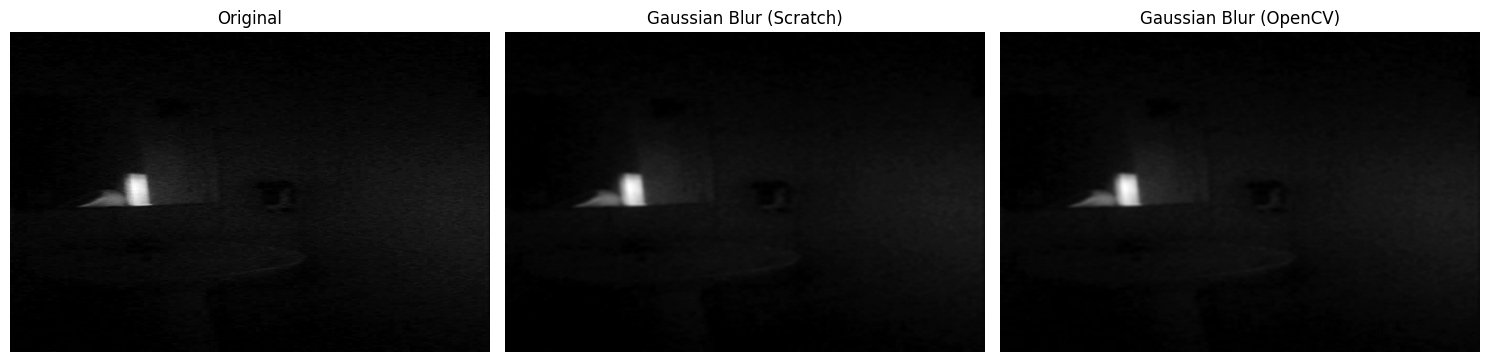

In [9]:
# --- 3.1 Gaussian Kernel and Convolution FROM SCRATCH ---
def create_gaussian_kernel(size, sigma=1.0):
    k = size // 2
    x, y = np.mgrid[-k : k + 1, -k : k + 1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g = normal * np.exp(-((x**2 + y**2) / (2.0 * sigma**2)))
    return g / g.sum()


def convolve_2d_scratch(image, kernel):
    return convolve2d(image, kernel, mode="same", boundary="symm").astype(np.uint8)


kernel_size = 5
sigma = 1.5
gau_kernel = create_gaussian_kernel(kernel_size, sigma)
print("Mathematical Gaussian Kernel:\n", np.round(gau_kernel, 3))

blurred_scratch = convolve_2d_scratch(gray_scratch, gau_kernel)
blurred_cv2 = cv2.GaussianBlur(gray_scratch, (kernel_size, kernel_size), sigmaX=sigma)

show_images(
    [gray_scratch, blurred_scratch, blurred_cv2],
    ["Original", "Gaussian Blur (Scratch)", "Gaussian Blur (OpenCV)"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


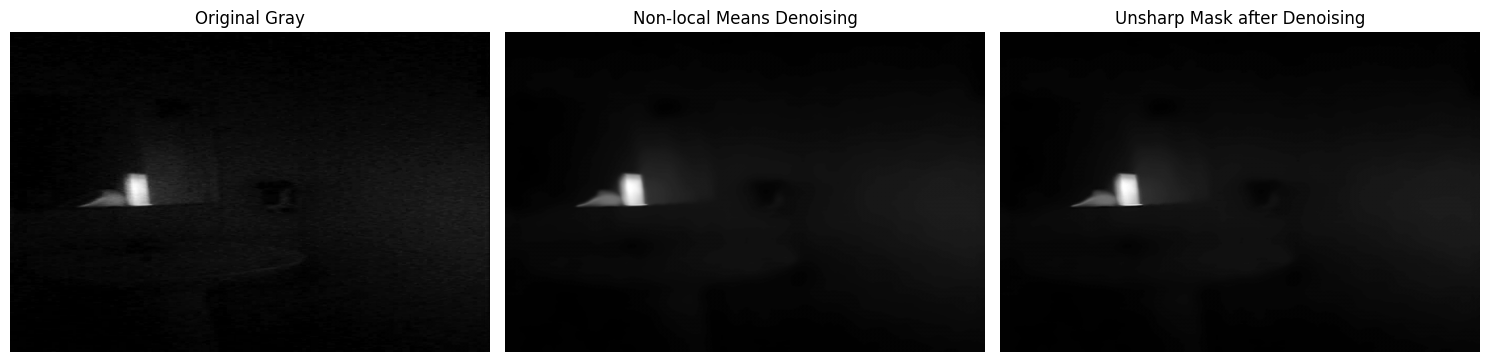

In [10]:
# --- 3.2 Optional Denoising and Unsharp Mask ---
denoised = cv2.fastNlMeansDenoising(gray_scratch, None, h=7, templateWindowSize=7, searchWindowSize=21)

def unsharp_mask(gray_img, sigma=1.0, amount=1.0):
    blurred = cv2.GaussianBlur(gray_img, (0, 0), sigmaX=sigma)
    sharpened = cv2.addWeighted(gray_img, 1.0 + amount, blurred, -amount, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


sharpened = unsharp_mask(denoised, sigma=1.0, amount=0.8)

show_images(
    [gray_scratch, denoised, sharpened],
    ["Original Gray", "Non-local Means Denoising", "Unsharp Mask after Denoising"],
    figsize=(15, 4),
    color_spaces=["gray", "gray", "gray"],
)


## 5. Morphological Operations

Morphology becomes more meaningful once we create a binary mask or region proposal. That makes it useful for edge cleanup, small-noise removal, and region closing.

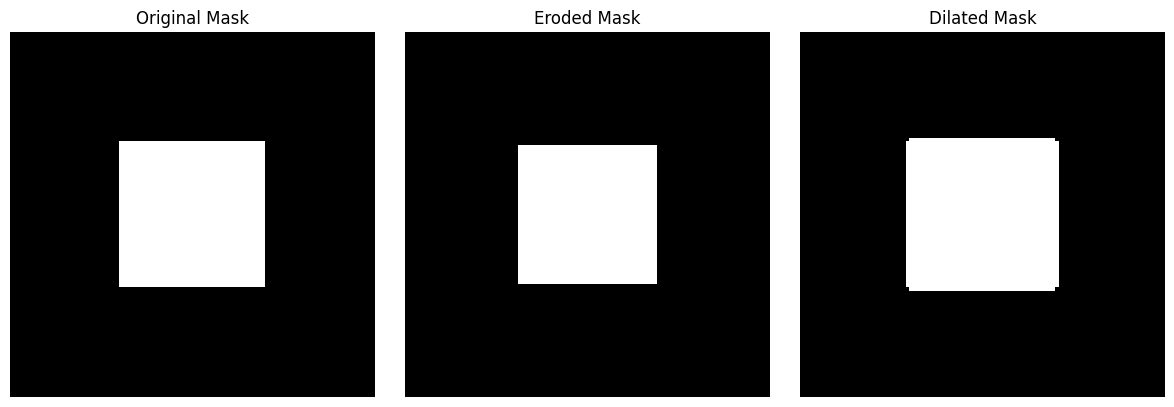

In [11]:
# --- 4.1 Erosion and Dilation FROM SCRATCH on a Synthetic Mask ---
mask = np.zeros((100, 100), dtype=np.uint8)
mask[30:70, 30:70] = 255

struct_elem = np.array(
    [
        [0, 1, 0],
        [1, 1, 1],
        [0, 1, 0],
    ],
    dtype=np.uint8,
)


def erode_scratch(img, kernel):
    pad = kernel.shape[0] // 2
    padded = np.pad(img, pad, mode="constant", constant_values=0)
    eroded = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i : i + kernel.shape[0], j : j + kernel.shape[1]]
            if np.all(region[kernel == 1] == 255):
                eroded[i, j] = 255
    return eroded


def dilate_scratch(img, kernel):
    pad = kernel.shape[0] // 2
    padded = np.pad(img, pad, mode="constant", constant_values=0)
    dilated = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i : i + kernel.shape[0], j : j + kernel.shape[1]]
            if np.any(region[kernel == 1] == 255):
                dilated[i, j] = 255
    return dilated


eroded_mask = erode_scratch(mask, struct_elem)
dilated_mask = dilate_scratch(mask, struct_elem)

show_images(
    [mask, eroded_mask, dilated_mask],
    ["Original Mask", "Eroded Mask", "Dilated Mask"],
    figsize=(12, 4),
    color_spaces=["gray", "gray", "gray"],
)


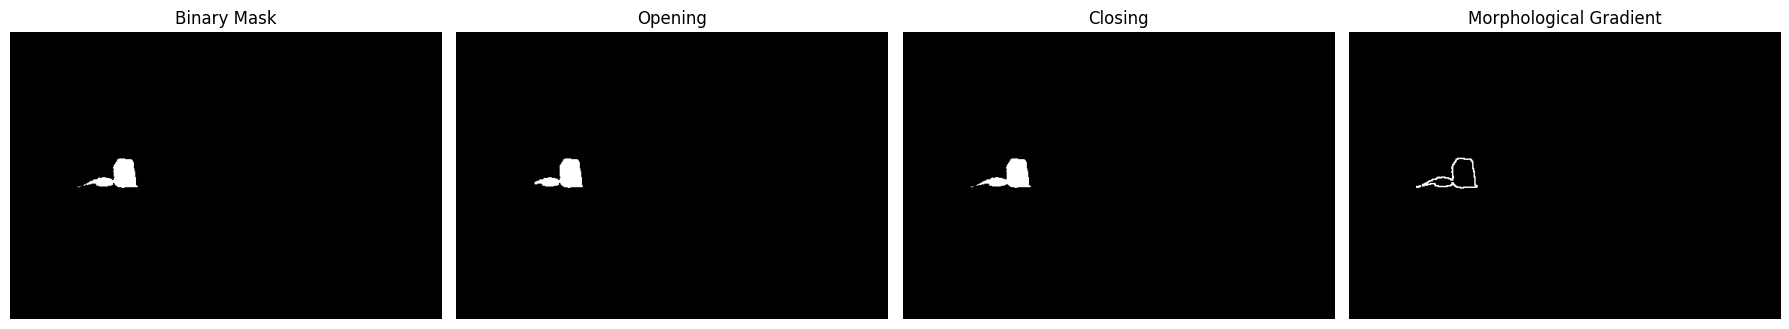

In [12]:
# --- 4.2 Morphology on a Real Binary Mask ---
_, binary = cv2.threshold(gray_scratch, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

show_images(
    [binary, opened, closed, gradient],
    ["Binary Mask", "Opening", "Closing", "Morphological Gradient"],
    figsize=(18, 5),
    color_spaces=["gray", "gray", "gray", "gray"],
)


## 6. Saved Preprocessing Pipeline

For the actual project, we want a compact pipeline that can be reused across many images. The version below keeps the baseline steps from the project and adds a few optional improvements: automatic brightness normalization, optional denoising, and optional sharpening.

{'gamma': 0.7, 'mean_before': 6.53, 'mean_after': 32.16}


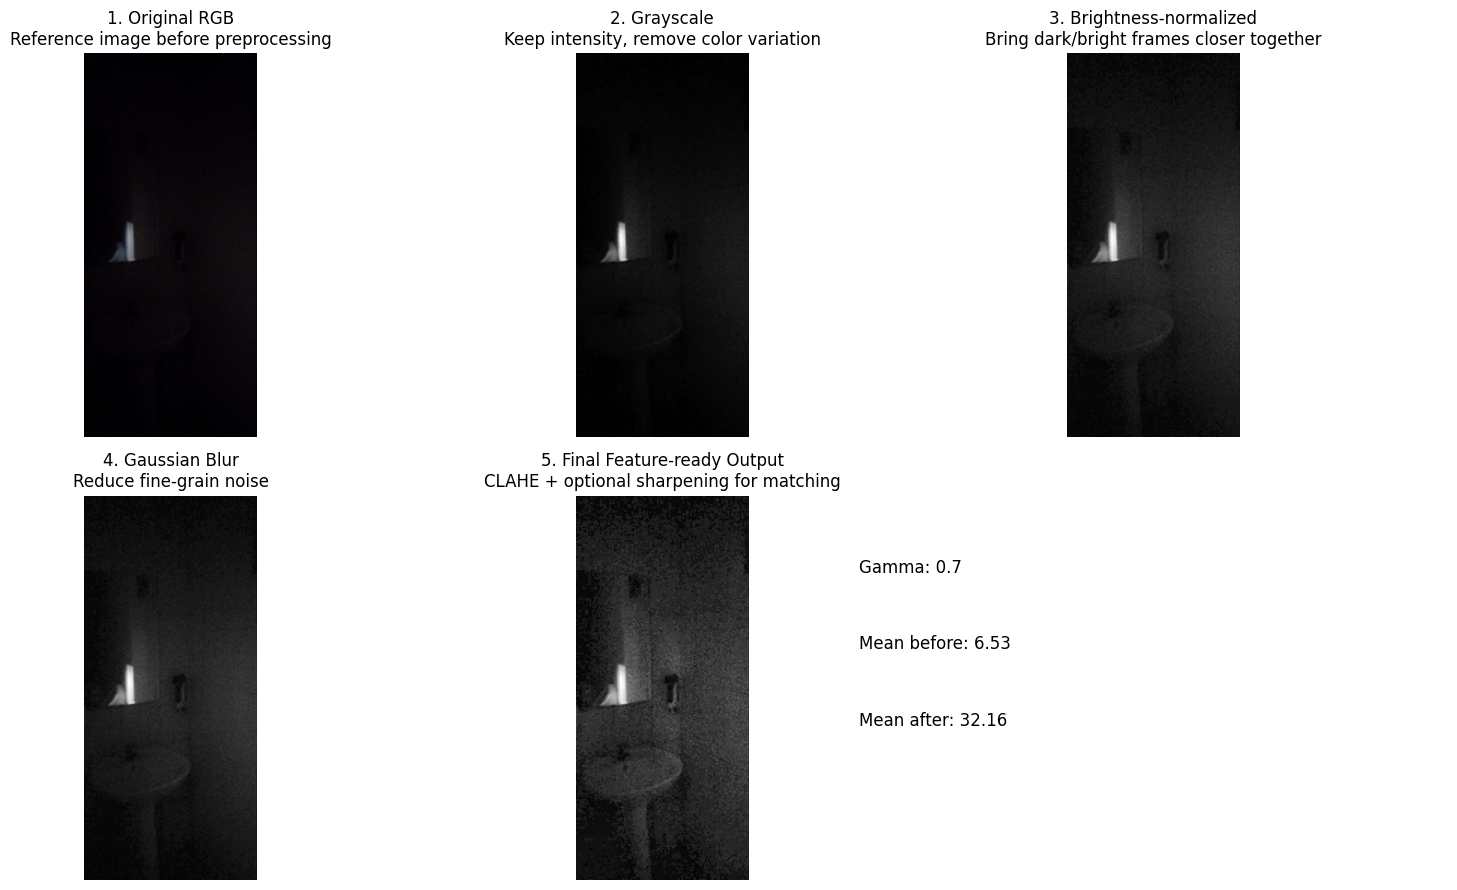

In [16]:
def automated_preprocessing_pipeline(
    img_path,
    max_width=800,
    apply_auto_brightness=True,
    apply_denoise=False,
    apply_clahe=True,
    apply_unsharp=False,
):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError(f"Image not found at {img_path}")

    # Step 1 - Resize: keep the aspect ratio but reduce resolution so matching runs faster.
    h, w = img_bgr.shape[:2]
    if w > max_width:
        ratio = max_width / float(w)
        img_bgr = cv2.resize(img_bgr, (max_width, int(h * ratio)), interpolation=cv2.INTER_AREA)

    # Step 2 - Grayscale conversion: remove color and keep intensity patterns for feature detection.
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Step 3 - Brightness normalization: pull dark/bright frames closer to a usable exposure range.
    gamma = 1.0
    normalized = gray.copy()
    if apply_auto_brightness:
        gamma = estimate_auto_gamma(gray)
        if abs(gamma - 1.0) > 0.03:
            normalized = adjust_gamma(gray, gamma)

    # Step 4 - Optional denoising: suppress sensor noise in hard low-light frames.
    filtered = normalized.copy()
    if apply_denoise:
        filtered = cv2.fastNlMeansDenoising(filtered, None, h=7, templateWindowSize=7, searchWindowSize=21)

    # Step 5 - Gaussian blur: lightly smooth tiny fluctuations before contrast enhancement.
    blurred = cv2.GaussianBlur(filtered, (3, 3), 0)

    # Step 6 - CLAHE: increase local contrast so weak textures are easier to detect.
    enhanced = blurred.copy()
    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(enhanced)

    # Step 7 - Optional unsharp mask: recover a bit of edge crispness in slightly soft frames.
    final_processed = enhanced.copy()
    if apply_unsharp:
        final_processed = unsharp_mask(final_processed, sigma=1.0, amount=0.8)

    meta = {
        "gamma": round(float(gamma), 3),
        "mean_before": round(float(gray.mean()), 2),
        "mean_after": round(float(final_processed.mean()), 2),
    }
    stages = {
        "rgb": img_rgb,
        "gray": gray,
        "normalized": normalized,
        "blurred": blurred,
        "final": final_processed,
    }
    return stages, meta


sample_path = "../data/split/failure_analysis/scene_18/img_001.jpg"
if os.path.exists(sample_path):
    stages, meta = automated_preprocessing_pipeline(
        sample_path,
        apply_auto_brightness=True,
        apply_denoise=False,
        apply_clahe=True,
        apply_unsharp=True,
    )
    print(meta)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.ravel()

    axes[0].imshow(stages["rgb"])
    axes[0].set_title("1. Original RGB\nReference image before preprocessing")
    axes[0].axis("off")

    axes[1].imshow(stages["gray"], cmap="gray")
    axes[1].set_title("2. Grayscale\nKeep intensity, remove color variation")
    axes[1].axis("off")

    axes[2].imshow(stages["normalized"], cmap="gray")
    axes[2].set_title("3. Brightness-normalized\nBring dark/bright frames closer together")
    axes[2].axis("off")

    axes[3].imshow(stages["blurred"], cmap="gray")
    axes[3].set_title("4. Gaussian Blur\nReduce fine-grain noise")
    axes[3].axis("off")

    axes[4].imshow(stages["final"], cmap="gray")
    axes[4].set_title("5. Final Feature-ready Output\nCLAHE + optional sharpening for matching")
    axes[4].axis("off")

    axes[5].axis("off")
    axes[5].text(0.0, 0.8, f"Gamma: {meta['gamma']}", fontsize=12)
    axes[5].text(0.0, 0.6, f"Mean before: {meta['mean_before']}", fontsize=12)
    axes[5].text(0.0, 0.4, f"Mean after: {meta['mean_after']}", fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print(f"Sample path {sample_path} not found. Extract the dataset to data/split before running this demo.")


### Full Preprocessing Pipeline Demonstration

The cell below is a configurable visual demo. It does not write files; it shows how the image changes after each preprocessing step so the report can compare choices such as OpenCV grayscale versus scratch grayscale, CLAHE versus global histogram equalization, and optional denoising or sharpening.


Demo image: data\split\failure_analysis\scene_18\img_001.jpg
Selected options:
  grayscale: opencv
  contrast: clahe
  auto gamma: False
  denoise: False
  gaussian: True
  unsharp: False
Mean intensity: before=6.53, final=15.89
Contrast std: before=8.74, final=12.85


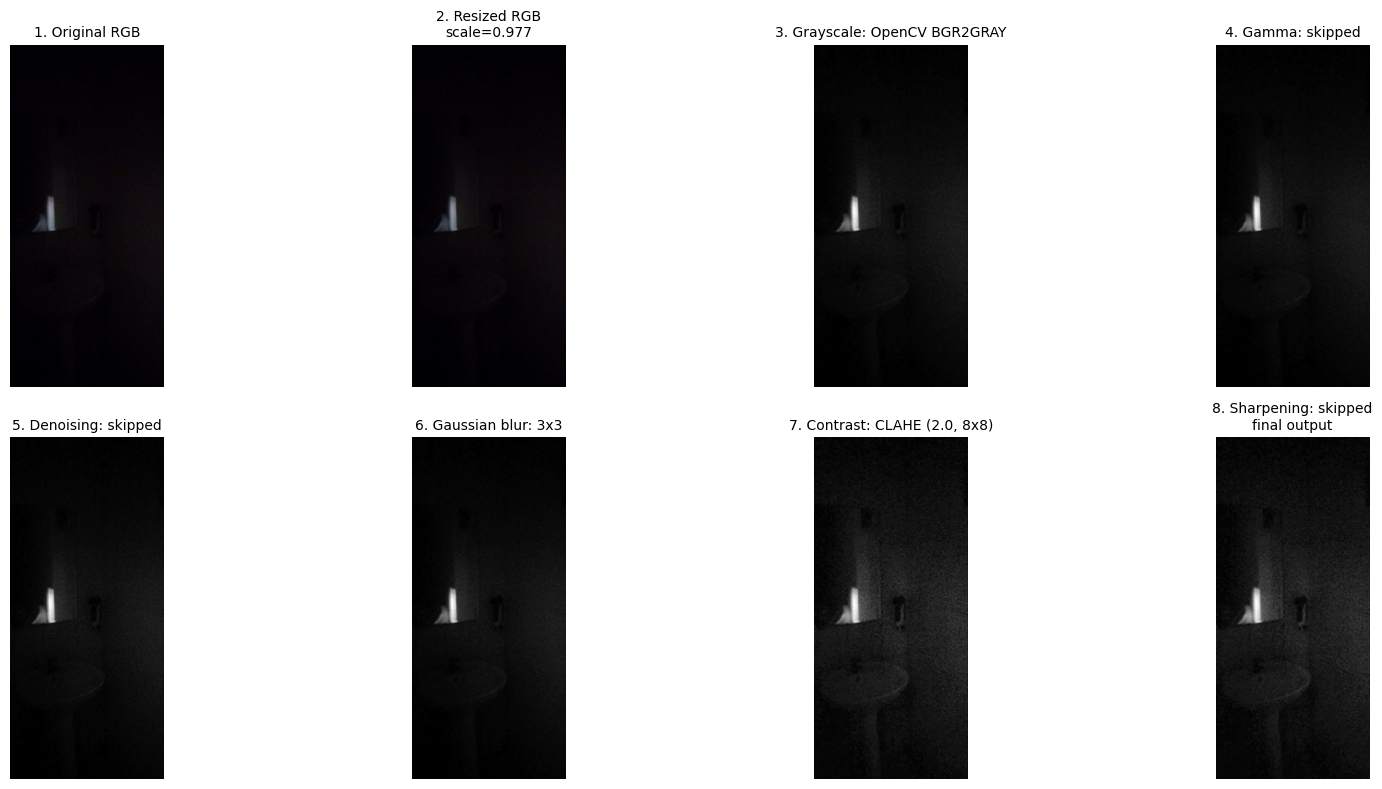

In [17]:
# --- 5.1 Full Configurable Preprocessing Pipeline Demo ---
from pathlib import Path

# Change these options to compare preprocessing variants.
DEMO_SPLIT = "failure_analysis"
DEMO_SCENE_ID = "scene_18"
DEMO_IMAGE_NAME = "img_001.jpg"
DEMO_MAX_WIDTH = 900

# Options: "opencv", "scratch"
DEMO_GRAYSCALE_METHOD = "opencv"

# Options: "none", "global_hist", "global_hist_scratch", "clahe"
DEMO_CONTRAST_METHOD = "clahe"

DEMO_USE_AUTO_GAMMA = False
DEMO_USE_DENOISE = False
DEMO_USE_GAUSSIAN = True
DEMO_USE_UNSHARP = False

DEMO_GAUSSIAN_KERNEL = 3
DEMO_CLAHE_CLIP_LIMIT = 2.0
DEMO_CLAHE_TILE_GRID = 8


def project_root_from_notebook():
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == "notebooks" else cwd


def resolve_demo_image_path():
    project_root = project_root_from_notebook()
    candidates = [
        project_root / "data" / "split" / DEMO_SPLIT / DEMO_SCENE_ID / DEMO_IMAGE_NAME,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find demo image in data/split. Extract the dataset into final_report/data first.")


def resize_keep_aspect_demo(image_bgr, max_width):
    height, width = image_bgr.shape[:2]
    if max_width <= 0 or width <= max_width:
        return image_bgr.copy(), 1.0
    scale = max_width / float(width)
    new_size = (max_width, max(1, int(round(height * scale))))
    return cv2.resize(image_bgr, new_size, interpolation=cv2.INTER_AREA), scale


def rgb_to_gray_scratch_local(image_rgb):
    weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
    gray = np.dot(image_rgb[..., :3], weights)
    return np.clip(gray, 0, 255).astype(np.uint8)


def hist_equalization_scratch_local(gray_img):
    hist, _ = np.histogram(gray_img.ravel(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_nonzero = np.ma.masked_equal(cdf, 0)
    cdf_scaled = (cdf_nonzero - cdf_nonzero.min()) * 255 / (cdf_nonzero.max() - cdf_nonzero.min())
    lookup = np.ma.filled(cdf_scaled, 0).astype(np.uint8)
    return lookup[gray_img]


def auto_gamma_local(gray_img, target_mean=128.0, gamma_min=0.7, gamma_max=1.5):
    current_mean = float(gray_img.mean())
    if current_mean <= 1.0 or current_mean >= 254.0:
        return 1.0
    current_norm = np.clip(current_mean / 255.0, 1e-4, 1 - 1e-4)
    target_norm = np.clip(target_mean / 255.0, 1e-4, 1 - 1e-4)
    gamma = np.log(target_norm) / np.log(current_norm)
    return float(np.clip(gamma, gamma_min, gamma_max))


def adjust_gamma_local(gray_img, gamma):
    # gamma < 1 brightens dark images; gamma > 1 darkens bright images.
    gamma = max(float(gamma), 1e-4)
    lookup = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(gray_img, lookup)


def unsharp_mask_local(gray_img, sigma=1.0, amount=0.8):
    blurred = cv2.GaussianBlur(gray_img, (0, 0), sigmaX=sigma)
    sharpened = cv2.addWeighted(gray_img, 1.0 + amount, blurred, -amount, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def apply_contrast_method(gray_img, method):
    if method == "none":
        return gray_img.copy(), "Contrast: none"
    if method == "global_hist":
        return cv2.equalizeHist(gray_img), "Contrast: global histogram equalization (OpenCV)"
    if method == "global_hist_scratch":
        return hist_equalization_scratch_local(gray_img), "Contrast: global histogram equalization (scratch)"
    if method == "clahe":
        clahe = cv2.createCLAHE(
            clipLimit=DEMO_CLAHE_CLIP_LIMIT,
            tileGridSize=(DEMO_CLAHE_TILE_GRID, DEMO_CLAHE_TILE_GRID),
        )
        return clahe.apply(gray_img), f"Contrast: CLAHE ({DEMO_CLAHE_CLIP_LIMIT}, {DEMO_CLAHE_TILE_GRID}x{DEMO_CLAHE_TILE_GRID})"
    raise ValueError(f"Unknown contrast method: {method}")


def run_full_preprocessing_demo():
    image_path = resolve_demo_image_path()
    original_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if original_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    resized_bgr, scale = resize_keep_aspect_demo(original_bgr, DEMO_MAX_WIDTH)
    resized_rgb = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB)

    if DEMO_GRAYSCALE_METHOD == "opencv":
        gray = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2GRAY)
        gray_title = "Grayscale: OpenCV BGR2GRAY"
    elif DEMO_GRAYSCALE_METHOD == "scratch":
        gray = rgb_to_gray_scratch_local(resized_rgb)
        gray_title = "Grayscale: scratch luminance formula"
    else:
        raise ValueError(f"Unknown grayscale method: {DEMO_GRAYSCALE_METHOD}")

    gamma = 1.0
    normalized = gray.copy()
    gamma_title = "Gamma: skipped"
    if DEMO_USE_AUTO_GAMMA:
        gamma = auto_gamma_local(gray)
        normalized = adjust_gamma_local(gray, gamma)
        gamma_title = f"Gamma normalization: gamma={gamma:.3f}"

    denoised = normalized.copy()
    denoise_title = "Denoising: skipped"
    if DEMO_USE_DENOISE:
        denoised = cv2.fastNlMeansDenoising(denoised, None, h=7, templateWindowSize=7, searchWindowSize=21)
        denoise_title = "Denoising: non-local means"

    gaussian_ready = denoised.copy()
    gaussian_title = "Gaussian blur: skipped"
    if DEMO_USE_GAUSSIAN:
        kernel = max(1, int(DEMO_GAUSSIAN_KERNEL))
        if kernel % 2 == 0:
            kernel += 1
        if kernel > 1:
            gaussian_ready = cv2.GaussianBlur(gaussian_ready, (kernel, kernel), 0)
            gaussian_title = f"Gaussian blur: {kernel}x{kernel}"

    contrasted, contrast_title = apply_contrast_method(gaussian_ready, DEMO_CONTRAST_METHOD)

    final = contrasted.copy()
    unsharp_title = "Sharpening: skipped"
    if DEMO_USE_UNSHARP:
        final = unsharp_mask_local(final, sigma=1.0, amount=0.8)
        unsharp_title = "Sharpening: unsharp mask"

    stages = [
        ("1. Original RGB", cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB), None),
        (f"2. Resized RGB\nscale={scale:.3f}", resized_rgb, None),
        (f"3. {gray_title}", gray, "gray"),
        (f"4. {gamma_title}", normalized, "gray"),
        (f"5. {denoise_title}", denoised, "gray"),
        (f"6. {gaussian_title}", gaussian_ready, "gray"),
        (f"7. {contrast_title}", contrasted, "gray"),
        (f"8. {unsharp_title}\nfinal output", final, "gray"),
    ]

    print("Demo image:", image_path.relative_to(project_root_from_notebook()))
    print("Selected options:")
    print("  grayscale:", DEMO_GRAYSCALE_METHOD)
    print("  contrast:", DEMO_CONTRAST_METHOD)
    print("  auto gamma:", DEMO_USE_AUTO_GAMMA)
    print("  denoise:", DEMO_USE_DENOISE)
    print("  gaussian:", DEMO_USE_GAUSSIAN)
    print("  unsharp:", DEMO_USE_UNSHARP)
    print(f"Mean intensity: before={gray.mean():.2f}, final={final.mean():.2f}")
    print(f"Contrast std: before={gray.std():.2f}, final={final.std():.2f}")

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, (title, image, cmap) in zip(axes.ravel(), stages):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return final


final_demo_image = run_full_preprocessing_demo()


### Optional Full-Scene Preprocessing Export

This optional cell creates the actual input files for notebook `03`. It reads every ordered image in one scene from `data/split/<split>/<scene>/`, applies the selected preprocessing policy, and saves the final feature-ready grayscale images to:

```text
data/preprocessing/<split>/feature_gray/<scene>/
```

The feature/descriptor notebook reads from that folder, so it does not need to run preprocessing again. Keep `RUN_SCENE_PREPROCESSING_EXPORT = False` during normal explanation-only runs; set it to `True` when you want to generate the preprocessed files for one selected scene.


Saved export gallery: C:\Users\PC\Downloads\Project\outputs\preprocessing\scene_gallery\failure_analysis_scene_18_feature_gray_export.png


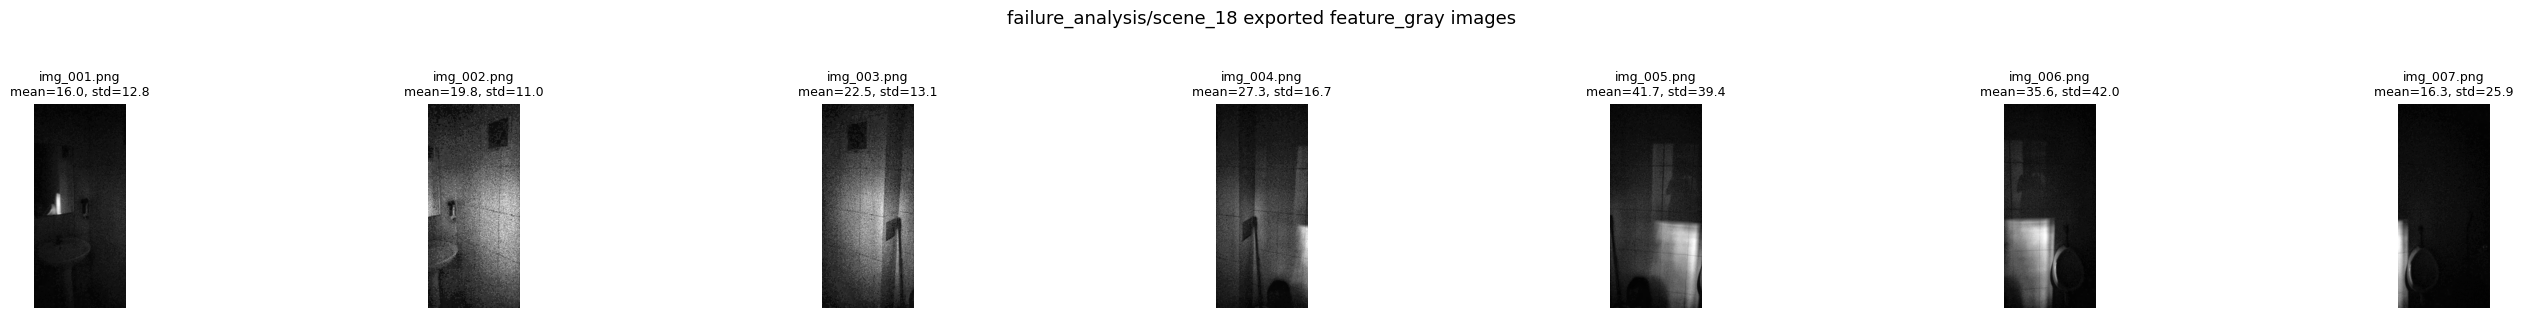

Input scene: data\split\failure_analysis\scene_18
Used meta order: True
Saved feature-gray folder: data\preprocessing\failure_analysis\feature_gray\scene_18
Scene manifest: data\preprocessing\failure_analysis\feature_gray\scene_18\preprocess_manifest.csv
Split-scene manifest: data\preprocessing\failure_analysis\scene_18_preprocess_manifest.csv


,split,scene_id,source_image,output_image,output_kind,applied_steps,gamma,brightness_before,brightness_after,contrast_before,contrast_after,blur_before,blur_after,generated_at
0,failure_analysis,scene_18,data\split\failure_analysis\scene_18\img_001.jpg,data\preprocessing\failure_analysis\feature_gr...,feature_gray,"gaussian:3,clahe:2.0/8x8",1.0,6.53,15.97,8.74,12.85,1.82,4.13,2026-05-24T13:35:51
1,failure_analysis,scene_18,data\split\failure_analysis\scene_18\img_002.jpg,data\preprocessing\failure_analysis\feature_gr...,feature_gray,"gaussian:3,clahe:2.0/8x8",1.0,8.96,19.77,6.64,11.01,2.38,5.41,2026-05-24T13:35:51
2,failure_analysis,scene_18,data\split\failure_analysis\scene_18\img_003.jpg,data\preprocessing\failure_analysis\feature_gr...,feature_gray,"gaussian:3,clahe:2.0/8x8",1.0,10.73,22.47,7.73,13.07,2.50,5.95,2026-05-24T13:35:51
3,failure_analysis,scene_18,data\split\failure_analysis\scene_18\img_004.jpg,data\preprocessing\failure_analysis\feature_gr...,feature_gray,"gaussian:3,clahe:2.0/8x8",1.0,13.63,27.25,10.17,16.66,3.19,6.93,2026-05-24T13:35:51
4,failure_analysis,scene_18,data\split\failure_analysis\scene_18\img_005.jpg,data\preprocessing\failure_analysis\feature_gr...,feature_gray,"gaussian:3,clahe:2.0/8x8",1.0,25.91,41.70,32.07,39.41,3.42,7.22,2026-05-24T13:35:51
5,failure_analysis,scene_18,data\split\failure_analysis\scene_18\img_006.jpg,data\preprocessing\failure_analysis\feature_gr...,feature_gray,"gaussian:3,clahe:2.0/8x8",1.0,22.11,35.65,34.01,42.01,2.80,5.86,2026-05-24T13:35:51
6,failure_analysis,scene_18,data\split\failure_analysis\scene_18\img_007.jpg,data\preprocessing\failure_analysis\feature_gr...,feature_gray,"gaussian:3,clahe:2.0/8x8",1.0,7.11,16.29,16.80,25.86,1.44,3.45,2026-05-24T13:35:51


In [18]:
# --- 5.2 Optional Full-Scene Preprocessing Export ---
import csv
import json
import sys
from datetime import datetime
from pathlib import Path

import pandas as pd

RUN_SCENE_PREPROCESSING_EXPORT = True

# Defaults match the current notebook 03 case-study scene.
SCENE_EXPORT_SPLIT = "failure_analysis"
SCENE_EXPORT_ID = "scene_18"

SCENE_EXPORT_OVERWRITE = True
SCENE_EXPORT_SHOW_GALLERY = True
SCENE_EXPORT_SAVE_GALLERY = True
SCENE_EXPORT_MAX_DISPLAY_COLS = 10

# Baseline export policy: resize -> grayscale -> Gaussian blur -> CLAHE.
SCENE_EXPORT_MAX_WIDTH = 1600
SCENE_EXPORT_ENABLE_AUTO_GAMMA = False
SCENE_EXPORT_TARGET_BRIGHTNESS = 128.0
SCENE_EXPORT_GAMMA_MIN = 0.7
SCENE_EXPORT_GAMMA_MAX = 1.5
SCENE_EXPORT_ENABLE_DENOISE = False
SCENE_EXPORT_ENABLE_GAUSSIAN = True
SCENE_EXPORT_GAUSSIAN_KERNEL = 3
SCENE_EXPORT_ENABLE_CLAHE = True
SCENE_EXPORT_CLAHE_CLIP_LIMIT = 2.0
SCENE_EXPORT_CLAHE_TILE_GRID = 8
SCENE_EXPORT_ENABLE_UNSHARP = False


def project_root_for_scene_export() -> Path:
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == "notebooks" else cwd


PROJECT_ROOT_EXPORT = project_root_for_scene_export()
if str(PROJECT_ROOT_EXPORT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT_EXPORT))

from project_utils.panorama_dataset import ordered_scene_files
from project_utils.preprocessing import PreprocessConfig, preprocess_feature_image


def build_scene_export_config() -> PreprocessConfig:
    gaussian_kernel = SCENE_EXPORT_GAUSSIAN_KERNEL if SCENE_EXPORT_ENABLE_GAUSSIAN else 1
    return PreprocessConfig(
        max_width=SCENE_EXPORT_MAX_WIDTH,
        gaussian_kernel=gaussian_kernel,
        clahe_clip_limit=SCENE_EXPORT_CLAHE_CLIP_LIMIT,
        clahe_tile_grid_size=SCENE_EXPORT_CLAHE_TILE_GRID,
        enable_clahe=SCENE_EXPORT_ENABLE_CLAHE,
        enable_brightness_normalization=SCENE_EXPORT_ENABLE_AUTO_GAMMA,
        target_brightness=SCENE_EXPORT_TARGET_BRIGHTNESS,
        gamma_min=SCENE_EXPORT_GAMMA_MIN,
        gamma_max=SCENE_EXPORT_GAMMA_MAX,
        enable_denoise=SCENE_EXPORT_ENABLE_DENOISE,
        enable_unsharp=SCENE_EXPORT_ENABLE_UNSHARP,
    )


def resolve_scene_export_paths() -> tuple[Path, Path, Path, Path]:
    split_scene_dir = PROJECT_ROOT_EXPORT / "data" / "split" / SCENE_EXPORT_SPLIT / SCENE_EXPORT_ID
    preprocessing_split_dir = PROJECT_ROOT_EXPORT / "data" / "preprocessing" / SCENE_EXPORT_SPLIT
    feature_scene_dir = preprocessing_split_dir / "feature_gray" / SCENE_EXPORT_ID
    gallery_dir = PROJECT_ROOT_EXPORT / "outputs" / "preprocessing" / "scene_gallery"

    if not split_scene_dir.is_dir():
        raise FileNotFoundError(f"Split scene folder not found: {split_scene_dir}")
    return split_scene_dir, preprocessing_split_dir, feature_scene_dir, gallery_dir


def write_scene_manifest(manifest_path: Path, rows: list[dict]) -> None:
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "split",
        "scene_id",
        "source_image",
        "output_image",
        "output_kind",
        "applied_steps",
        "gamma",
        "brightness_before",
        "brightness_after",
        "contrast_before",
        "contrast_after",
        "blur_before",
        "blur_after",
        "generated_at",
    ]
    with manifest_path.open("w", encoding="utf-8-sig", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def show_scene_export_gallery(records: list[dict], gallery_path: Path | None = None) -> None:
    if not records:
        return

    cols = min(SCENE_EXPORT_MAX_DISPLAY_COLS, len(records))
    rows = (len(records) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.2 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, record in zip(axes, records):
        ax.imshow(record["final_gray"], cmap="gray")
        ax.set_title(
            f"{record['output_path'].name}\nmean={record['metrics_after']['brightness_mean']:.1f}, "
            f"std={record['metrics_after']['contrast_std']:.1f}",
            fontsize=9,
        )
        ax.axis("off")

    fig.suptitle(
        f"{SCENE_EXPORT_SPLIT}/{SCENE_EXPORT_ID} exported feature_gray images",
        fontsize=13,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    if gallery_path is not None:
        gallery_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(gallery_path, dpi=180, bbox_inches="tight")
        print("Saved export gallery:", gallery_path)

    plt.show()


def export_scene_preprocessing() -> tuple[pd.DataFrame, Path]:
    split_scene_dir, preprocessing_split_dir, feature_scene_dir, gallery_dir = resolve_scene_export_paths()
    ordered_files, reference_files, _, used_meta_order = ordered_scene_files(split_scene_dir)

    if not ordered_files:
        raise ValueError(f"No ordered images found in {split_scene_dir}")

    feature_scene_dir.mkdir(parents=True, exist_ok=True)
    config = build_scene_export_config()
    generated_at = datetime.now().isoformat(timespec="seconds")

    manifest_rows = []
    display_records = []

    for image_path in ordered_files:
        output_path = feature_scene_dir / f"{image_path.stem}.png"
        if output_path.exists() and not SCENE_EXPORT_OVERWRITE:
            print(f"Keeping existing file: {output_path}")
            continue

        image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            print(f"Skipping unreadable image: {image_path}")
            continue

        result = preprocess_feature_image(image_bgr, config=config)
        final_gray = result["final"]

        if not cv2.imwrite(str(output_path), final_gray):
            raise OSError(f"Could not write preprocessed image: {output_path}")

        before = result["metrics_before"]
        after = result["metrics_after"]
        row = {
            "split": SCENE_EXPORT_SPLIT,
            "scene_id": SCENE_EXPORT_ID,
            "source_image": str(image_path.relative_to(PROJECT_ROOT_EXPORT)),
            "output_image": str(output_path.relative_to(PROJECT_ROOT_EXPORT)),
            "output_kind": "feature_gray",
            "applied_steps": ",".join(result["applied_steps"]),
            "gamma": round(float(result["gamma"]), 3),
            "brightness_before": round(float(before["brightness_mean"]), 2),
            "brightness_after": round(float(after["brightness_mean"]), 2),
            "contrast_before": round(float(before["contrast_std"]), 2),
            "contrast_after": round(float(after["contrast_std"]), 2),
            "blur_before": round(float(before["blur_score"]), 2),
            "blur_after": round(float(after["blur_score"]), 2),
            "generated_at": generated_at,
        }
        manifest_rows.append(row)
        display_records.append(
            {
                "output_path": output_path,
                "final_gray": final_gray,
                "metrics_after": after,
            }
        )

    if not manifest_rows:
        raise ValueError("No images were exported. Check SCENE_EXPORT_OVERWRITE or input readability.")

    scene_manifest_path = feature_scene_dir / "preprocess_manifest.csv"
    split_manifest_path = preprocessing_split_dir / f"{SCENE_EXPORT_ID}_preprocess_manifest.csv"
    write_scene_manifest(scene_manifest_path, manifest_rows)
    write_scene_manifest(split_manifest_path, manifest_rows)

    gallery_path = None
    if SCENE_EXPORT_SAVE_GALLERY:
        gallery_path = gallery_dir / f"{SCENE_EXPORT_SPLIT}_{SCENE_EXPORT_ID}_feature_gray_export.png"

    if SCENE_EXPORT_SHOW_GALLERY:
        show_scene_export_gallery(display_records, gallery_path=gallery_path)

    summary_df = pd.DataFrame(manifest_rows)
    print("Input scene:", split_scene_dir.relative_to(PROJECT_ROOT_EXPORT))
    print("Used meta order:", used_meta_order)
    if reference_files:
        print("Reference files excluded:", [path.name for path in reference_files])
    print("Saved feature-gray folder:", feature_scene_dir.relative_to(PROJECT_ROOT_EXPORT))
    print("Scene manifest:", scene_manifest_path.relative_to(PROJECT_ROOT_EXPORT))
    print("Split-scene manifest:", split_manifest_path.relative_to(PROJECT_ROOT_EXPORT))
    try:
        display(summary_df)
    except NameError:
        print(summary_df)

    return summary_df, feature_scene_dir


if RUN_SCENE_PREPROCESSING_EXPORT:
    scene_export_summary, scene_export_dir = export_scene_preprocessing()
else:
    print(
        "Set RUN_SCENE_PREPROCESSING_EXPORT = True to write "
        "data/preprocessing/<split>/feature_gray/<scene>/*.png for notebook 03."
    )


## 7. Preprocessing Limits for Failure Cases

Preprocessing mainly helps photometric and local-detail problems: exposure change, low contrast, mild blur, and weak texture. It cannot fully repair geometry or capture problems such as missing overlap, strong parallax, repeated-pattern ambiguity, moving objects, or long translated scans.

| Failure case | Example scene | Can preprocessing help? | Preprocessing to try | Better response when preprocessing is not enough |
|---|---:|---|---|---|
| Low texture | `scene_11` | Partially | CLAHE, gamma normalization, mild sharpening | Use stronger descriptors, add more textured views, or recapture |
| Exposure change | `scene_30` | Often yes | Gamma correction, brightness normalization, CLAHE, histogram matching | Keep exposure more consistent during capture |
| Motion blur | `scene_35` | Slightly | Mild sharpening or unsharp mask, careful denoising | Drop blurry frames or choose sharper captures |
| Moving objects | `scene_35` | Usually no | Mask dynamic regions if available | Remove affected frames or rely on static background matches |
| Repeated patterns | `scene_32` | Usually no | Mild contrast only; avoid over-enhancement | Use stricter RANSAC/geometric checks or inspect matches manually |
| Parallax | `scene_15`, `scene_16` | No | Not a preprocessing issue | Use local warping, split the scene, or recapture with rotation around one viewpoint |
| Insufficient overlap | `scene_04` | No | Not fixable by contrast or filtering | Recapture with more overlap, drop the broken transition, or split the scene |
| Sideways scan / translated capture | `scene_15`, `scene_16` | Mostly no | Crop or split only as a diagnostic step | Use a different stitching model or avoid treating it as a pure panorama |
| Global stitch failure | `scene_08` | Sometimes | Standardized resize, CLAHE, brightness normalization | Split the chain or inspect whether OpenCV rejects global camera estimation |
| Wide sweep / long chain | `scene_21` | Partially | Exposure normalization and consistent resize | Reduce chain length, select fewer frames, or stitch in smaller groups |
| Output variation / instability | `scene_30` | Partially | Fixed input order, fixed resize, consistent preprocessing | Repeat runs, compare logs, and keep the most stable configuration |

For this project, preprocessing should be presented as a feature-quality improvement step, not as a universal failure repair step. If the failure is caused by missing shared content or inconsistent 3D geometry, the correct fix is usually scene selection, frame pruning, recapture, or a different stitching model.


## 8. Batch Processing Strategy


The notebook explains the preprocessing logic, but the real dataset should be processed with `scripts/PhamHungSon_15_apply_preprocessing.py`. The script reads scenes from `data/split/...` and writes generated outputs under `data/preprocessing/...`; it does not modify the downloaded split images.

### Environment
If the `image_recognition` environment is already activated, use `python`. If not, replace `python` with:

```bash
conda run -n image_recognition python
```

### Where outputs are saved
- test split: `data/preprocessing/test`
- failure analysis split: `data/preprocessing/failure_analysis`
- development split remains available for internal development runs: `data/preprocessing/development`

### Run on each split
```bash
python scripts/PhamHungSon_15_apply_preprocessing.py --split test --ordered-only --profile baseline --output-kind gray --overwrite
python scripts/PhamHungSon_15_apply_preprocessing.py --split failure_analysis --ordered-only --profile baseline --output-kind gray --overwrite
```

### Run on selected scenes
```bash
python scripts/PhamHungSon_15_apply_preprocessing.py --split test --scene scene_01 --scene scene_36 --ordered-only
python scripts/PhamHungSon_15_apply_preprocessing.py --split failure_analysis --scene scene_08 --scene scene_32 --ordered-only
```

### Run on selected images
```bash
python scripts/PhamHungSon_15_apply_preprocessing.py --split failure_analysis --image scene_04/img_01.jpg
```

### Choose the preprocessing policy
```bash
python scripts/PhamHungSon_15_apply_preprocessing.py --split test --profile baseline --ordered-only
python scripts/PhamHungSon_15_apply_preprocessing.py --split failure_analysis --scene scene_18 --ordered-only --profile enhanced --output-kind both --target-brightness 155 --gamma-min 0.35 --clahe-clip-limit 3.0 --denoise --unsharp --overwrite
python scripts/PhamHungSon_15_apply_preprocessing.py --split failure_analysis --profile audit_auto --ordered-only
```

`baseline` keeps the standard resize + Gaussian blur + CLAHE flow. `enhanced` enables optional denoising/sharpening when explicitly requested. `audit_auto` uses recommendations from `outputs/audit/image_metrics.csv` if that CSV exists; otherwise it falls back to the baseline CLAHE pipeline.
